Loading CLIP Models...


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 208MB/s]


-> No checkpoint found. Starting training from scratch...


Epoch [20/20]: 100%|██████████| 1739/1739 [27:14<00:00,  1.06it/s, D_loss=0.47, G_loss=2.19]


Training Complete.
Generating Loss Graphs...
Loss graphs saved to sota_outputs/training_loss_curves.png
Running final evaluation on validation set...
Evaluation complete! Check the 'sota_eval_outputs' folder.


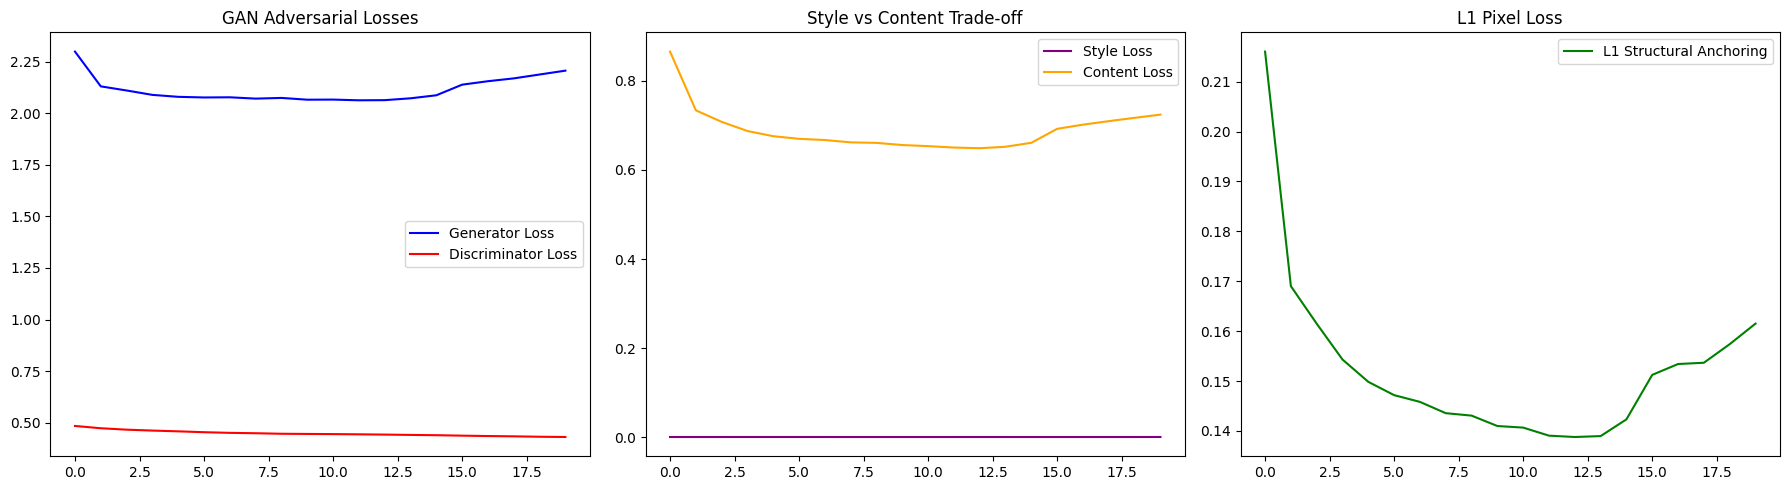

In [1]:
import os
import glob
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg19, VGG19_Weights
from torchvision.utils import save_image, make_grid
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import CLIPTokenizer, CLIPTextModelWithProjection, CLIPVisionModelWithProjection
import numpy as np

# ==========================================
# CONFIGURATION & HYPERPARAMETERS
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
EPOCHS = 20
LR_G = 0.0002
LR_D = 0.0002
IMAGE_SIZE = 256
CHECKPOINT_DIR = "checkpoints_sota"
OUTPUT_DIR = "sota_outputs"
EVAL_DIR = "sota_eval_outputs" 
CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

# Update these paths to your actual kaggle/local directories
REAL_DIRS = ["/kaggle/input/datasets/tonystark1212/anime-movies/dataset/lost_in_translation", "/kaggle/input/datasets/tonystark1212/anime-movies/dataset/planet_earth_3"]
ANIME_DIRS = ["/kaggle/input/datasets/tonystark1212/anime-movies/dataset/suzume", "/kaggle/input/datasets/tonystark1212/anime-movies/dataset/your_name"]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

# ==========================================
# 1. DATASET (UPDATED FOR SHARP DETAILS)
# ==========================================
class TextPairedDomainDataset(Dataset):
    def __init__(self, real_dirs, anime_dirs):
        self.real_images = []
        for d in real_dirs:
            if os.path.exists(d): self.real_images.extend(glob.glob(os.path.join(d, "*.jpg")))
            
        self.anime_images = []
        for d in anime_dirs:
            if os.path.exists(d): self.anime_images.extend(glob.glob(os.path.join(d, "*.jpg")))

        self.length = max(len(self.real_images), len(self.anime_images))
        
        self.prompts = [
            "2D vector art, flat cel shading, heavy outline strokes, hand-drawn anime background art",
            "Vibrant Makoto Shinkai painting, zero photorealism, anime illustration",
            "Studio Ghibli style cinematic anime scene, painted background",
            "Flat 2D anime art with glowing lighting, pure illustration"
        ]

        self.geom_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip()
        ])
        
        self.norm_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self): return self.length

    def __getitem__(self, index):
        real_path = self.real_images[index % len(self.real_images)]
        anime_path = random.choice(self.anime_images) 
        prompt = random.choice(self.prompts)

        real_img_pil = self.geom_transform(Image.open(real_path).convert("RGB"))
        anime_img_pil = self.geom_transform(Image.open(anime_path).convert("RGB"))

        # --- UPDATED OPENCV PROCESSING ---
        img_np = np.array(real_img_pil)
        simplified = cv2.pyrMeanShiftFiltering(img_np, sp=10, sr=30)
        gray = cv2.cvtColor(simplified, cv2.COLOR_RGB2GRAY)
        
        # 1. Edge Stencil: Reduced kernel size to prevent blobs, removed heavy morphology
        edges = cv2.Canny(gray, threshold1=70, threshold2=150)
        kernel = np.ones((2, 2), np.uint8) # Thinner lines
        edges = cv2.dilate(edges, kernel, iterations=1)
        edges = cv2.GaussianBlur(edges, (3, 3), 0)
        
        edges = (edges / 255.0).astype(np.float32)
        edges_tensor = torch.from_numpy(edges).unsqueeze(0)
        edges_tensor = (edges_tensor - 0.5) / 0.5 

        # 2. Color Hint: Switched to Bilateral Filter to keep edges (eyes) sharp while flattening colors
        hint = cv2.bilateralFilter(img_np, d=9, sigmaColor=75, sigmaSpace=75)
        hint_tensor = self.norm_transform(Image.fromarray(hint))

        real_input_4ch = torch.cat([edges_tensor, hint_tensor], dim=0)
        real_tensor = self.norm_transform(real_img_pil)
        anime_tensor = self.norm_transform(anime_img_pil)

        return real_input_4ch, anime_tensor, prompt, real_tensor

dataset = TextPairedDomainDataset(REAL_DIRS, ANIME_DIRS)
val_size = max(1, int(0.05 * len(dataset)))
train_size = len(dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 2. TEXT ENCODER SETUP (CLIP)
# ==========================================
print("Loading CLIP Models...")
clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
clip_text_model = CLIPTextModelWithProjection.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
clip_vision_model = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()

for param in clip_text_model.parameters(): param.requires_grad = False
for param in clip_vision_model.parameters(): param.requires_grad = False

def batched_box_filter(x, r): return F.avg_pool2d(x, kernel_size=2*r+1, stride=1, padding=r)

def batched_guided_filter(x, y, r=5, eps=1e-3):
    N = batched_box_filter(torch.ones_like(x), r)
    mean_x = batched_box_filter(x, r) / N
    mean_y = batched_box_filter(y, r) / N
    cov_xy = (batched_box_filter(x * y, r) / N) - mean_x * mean_y
    var_x = (batched_box_filter(x * x, r) / N) - mean_x * mean_x
    a = cov_xy / (var_x + eps)
    b = mean_y - a * mean_x
    return (batched_box_filter(a, r) / N) * x + (batched_box_filter(b, r) / N)

# ==========================================
# 3. ADVANCED SOTA LOSS FUNCTIONS
# ==========================================
class VGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        vgg_pretrained = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.to(DEVICE).eval()
        for param in vgg_pretrained.parameters(): param.requires_grad = False
        
        self.slice1 = nn.Sequential(*vgg_pretrained[:4])   # relu1_2 (High frequency details)
        self.slice2 = nn.Sequential(*vgg_pretrained[4:9])  # relu2_2 (Structure)
        self.slice3 = nn.Sequential(*vgg_pretrained[9:18]) # relu3_2
        self.slice4 = nn.Sequential(*vgg_pretrained[18:27]) # relu4_2

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

    def forward(self, x):
        x_norm = ((x + 1.0) / 2.0 - self.mean) / self.std
        h1 = self.slice1(x_norm)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return [h1, h2, h3, h4]

vgg_extractor = VGGFeatureExtractor()

def directional_clip_loss(real_img, fake_img, text_embeds):
    real_img = (real_img + 1.0) / 2.0
    fake_img = (fake_img + 1.0) / 2.0
    real_resized = F.interpolate(real_img, size=(224, 224), mode='bilinear', align_corners=False)
    fake_resized = F.interpolate(fake_img, size=(224, 224), mode='bilinear', align_corners=False)
    
    clip_mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1).to(DEVICE)
    clip_std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1).to(DEVICE)
    real_norm = (real_resized - clip_mean) / clip_std
    fake_norm = (fake_resized - clip_mean) / clip_std

    real_features = clip_vision_model(real_norm).image_embeds
    fake_features = clip_vision_model(fake_norm).image_embeds
    
    img_direction = F.normalize(fake_features - real_features, p=2, dim=-1)
    text_direction = F.normalize(text_embeds, p=2, dim=-1)
    return 1.0 - torch.cosine_similarity(img_direction, text_direction, dim=-1).mean()

def calc_style_loss(fake_features, anime_features):
    loss = 0
    for f_f, a_f in zip(fake_features, anime_features):
        b, c, h, w = f_f.size()
        G_fake = torch.bmm(f_f.view(b, c, h*w), f_f.view(b, c, h*w).transpose(1, 2)) / (c * h * w)
        G_anime = torch.bmm(a_f.view(b, c, h*w), a_f.view(b, c, h*w).transpose(1, 2)) / (c * h * w)
        loss += F.mse_loss(G_fake, G_anime)
    return loss

def calc_deep_content_loss(fake_features, real_features):
    # --- UPDATED FOR SHARP DETAILS ---
    # Layer [0] = relu1_2 (Forces high-frequency sharp edges, eyes, textures)
    # Layer [1] = relu2_2 (Forces mid-level structure, shapes)
    loss_sharp = F.l1_loss(fake_features[0], real_features[0])
    loss_struct = F.l1_loss(fake_features[1], real_features[1])
    return (loss_sharp * 0.5) + (loss_struct * 0.5)

# ==========================================
# 4. GENERATOR (UNET) & DISCRIMINATOR
# ==========================================
class CrossAttention(nn.Module):
    def __init__(self, in_dim, text_dim=512):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim//8, 1)
        self.key = nn.Linear(text_dim, in_dim//8)
        self.value = nn.Linear(text_dim, in_dim)
        self.gamma = nn.Parameter(torch.zeros(1))
        
    def forward(self, x, text_embeds):
        b, c, w, h = x.size()
        q = self.query(x).view(b, -1, w*h).permute(0, 2, 1)
        k = self.key(text_embeds).unsqueeze(2)
        v = self.value(text_embeds).unsqueeze(2)
        attn = torch.softmax(torch.bmm(q, k), dim=1)
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(b, c, w, h)
        return x + self.gamma * out

class ConvNormLReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.m = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, x): return self.m(x)

class InvertedResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.m = nn.Sequential(
            ConvNormLReLU(channels, channels*2, 1, 1, 0),
            nn.Conv2d(channels*2, channels*2, 3, 1, 1, groups=channels*2, bias=False),
            nn.InstanceNorm2d(channels*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels*2, channels, 1, 1, 0, bias=False),
            nn.InstanceNorm2d(channels)
        )
    def forward(self, x): return x + self.m(x)

class TextGuidedGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvNormLReLU(4, 32, 7, 1, 3)
        self.enc2 = ConvNormLReLU(32, 64, 3, 2, 1)
        self.enc3 = ConvNormLReLU(64, 128, 3, 2, 1)
        
        self.res_blocks = nn.Sequential(*[InvertedResBlock(128) for _ in range(4)])
        self.cross_attn = CrossAttention(128, text_dim=512)
        
        self.up1_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.up1_conv = ConvNormLReLU(128 + 64, 64, 3, 1, 1)
        
        self.up2_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.up2_conv = ConvNormLReLU(64 + 32, 32, 3, 1, 1)
        
        self.final = nn.Sequential(
            nn.Conv2d(32 + 4, 3, 7, 1, 3),
            nn.Tanh()
        )

    def forward(self, x, text_embeds):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        
        b = self.res_blocks(e3)
        b = self.cross_attn(b, text_embeds)
        
        u1 = self.up1_up(b)
        u1 = self.up1_conv(torch.cat([u1, e2], dim=1))
        
        u2 = self.up2_up(u1)
        u2 = self.up2_conv(torch.cat([u2, e1], dim=1))
        
        out = self.final(torch.cat([u2, x], dim=1))
        return out

class SpectralDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.m = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(3, 32, 3, 1, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(32, 64, 3, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(64, 128, 3, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(128, 256, 3, 1, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 3, 1, 1)
        )
    def forward(self, x): return self.m(x)

# ==========================================
# 5. SETUP & RESUME LOGIC
# ==========================================
criterion_GAN = nn.MSELoss()
G = TextGuidedGenerator().to(DEVICE)
D = SpectralDiscriminator().to(DEVICE)

opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))

start_epoch = 0
history_G_loss, history_D_loss = [], []
history_Style_loss, history_Content_loss, history_L1_loss = [], [], []

if os.path.exists(CHECKPOINT_FILE):
    print(f"-> Checkpoint found! Resuming from: {CHECKPOINT_FILE}")
    checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
    G.load_state_dict(checkpoint['G_state_dict'])
    D.load_state_dict(checkpoint['D_state_dict'])
    opt_G.load_state_dict(checkpoint['opt_G_state_dict'])
    opt_D.load_state_dict(checkpoint['opt_D_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
else:
    print("-> No checkpoint found. Starting training from scratch...")

# ==========================================
# 6. TRAINING LOOP
# ==========================================
for epoch in range(start_epoch, EPOCHS):
    G.train()
    D.train()
    
    loop = tqdm(train_loader, leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
    
    epoch_g_loss, epoch_d_loss = 0, 0
    epoch_style_loss, epoch_content_loss, epoch_l1_loss = 0, 0, 0

    for real_input_4ch, anime_img, prompts, real_img_3ch in loop:
        real_input_4ch = real_input_4ch.to(DEVICE)
        anime_img = anime_img.to(DEVICE)
        real_img_3ch = real_img_3ch.to(DEVICE)
        
        text_inputs = clip_tokenizer(list(prompts), padding=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad(): text_embeds = clip_text_model(**text_inputs).text_embeds
        
        smooth_img = batched_guided_filter(anime_img, anime_img, r=5)
        
        # --- Train Generator ---
        opt_G.zero_grad()
        
        fake_anime = G(real_input_4ch, text_embeds)
        pred_fake = D(fake_anime)
        
        loss_G_adv = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
        
        fake_vgg_feats = vgg_extractor(fake_anime)
        anime_vgg_feats = vgg_extractor(anime_img)
        real_vgg_feats = vgg_extractor(real_img_3ch)

        # Using your successfully tested weights
        loss_L1 = F.l1_loss(fake_anime, real_img_3ch) * 4.0
        loss_clip = directional_clip_loss(real_img_3ch, fake_anime, text_embeds) * 1.0
        loss_style = calc_style_loss(fake_vgg_feats, anime_vgg_feats) * 2.0
        loss_content = calc_deep_content_loss(fake_vgg_feats, real_vgg_feats) * 3.0 
        
        loss_G = loss_G_adv + loss_clip + loss_content + loss_style + loss_L1
        loss_G.backward()
        opt_G.step()

        # --- Train Discriminator ---
        opt_D.zero_grad()
        loss_D_real = criterion_GAN(D(anime_img), torch.ones_like(pred_fake))
        loss_D_fake = criterion_GAN(D(fake_anime.detach()), torch.zeros_like(pred_fake))
        loss_D_smooth = criterion_GAN(D(smooth_img), torch.zeros_like(pred_fake))

        loss_D = loss_D_real + ((loss_D_fake + loss_D_smooth) / 2.0)
        loss_D.backward()
        opt_D.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        epoch_style_loss += loss_style.item()
        epoch_content_loss += loss_content.item()
        epoch_l1_loss += loss_L1.item()

        loop.set_postfix(G_loss=f"{loss_G.item():.2f}", D_loss=f"{loss_D.item():.2f}")

    history_G_loss.append(epoch_g_loss / len(train_loader))
    history_D_loss.append(epoch_d_loss / len(train_loader))
    history_Style_loss.append(epoch_style_loss / len(train_loader))
    history_Content_loss.append(epoch_content_loss / len(train_loader))
    history_L1_loss.append(epoch_l1_loss / len(train_loader))

    # --- SAVE MASTER CHECKPOINT ---
    checkpoint = {
        'epoch': epoch,
        'G_state_dict': G.state_dict(),
        'D_state_dict': D.state_dict(),
        'opt_G_state_dict': opt_G.state_dict(),
        'opt_D_state_dict': opt_D.state_dict()
    }
    torch.save(checkpoint, CHECKPOINT_FILE)
    torch.save(G.state_dict(), f"{CHECKPOINT_DIR}/latest_G_weights.pth")
    torch.save(D.state_dict(), f"{CHECKPOINT_DIR}/latest_D_weights.pth")

print("Training Complete.")

# ==========================================
# 7. EVALUATION
# ==========================================
print("Generating Loss Graphs...")
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history_G_loss, label='Generator Loss', color='blue')
plt.plot(history_D_loss, label='Discriminator Loss', color='red')
plt.title("GAN Adversarial Losses")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_Style_loss, label='Style Loss', color='purple')
plt.plot(history_Content_loss, label='Content Loss', color='orange')
plt.title("Style vs Content Trade-off")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_L1_loss, label='L1 Structural Anchoring', color='green')
plt.title("L1 Pixel Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_loss_curves.png")
print(f"Loss graphs saved to {OUTPUT_DIR}/training_loss_curves.png")

print("Running final evaluation on validation set...")
G.eval()
val_batch_count = 0
with torch.no_grad():
    for real_input_4ch, anime_img, prompts, real_img_3ch in val_loader:
        if val_batch_count >= 5: break
            
        real_input_4ch = real_input_4ch.to(DEVICE)
        real_img_3ch = real_img_3ch.to(DEVICE)
        
        eval_prompt = ["2D vector art, flat cel shading, heavy outline strokes, hand-drawn anime background art"] * real_img_3ch.size(0)
        text_inputs = clip_tokenizer(eval_prompt, padding=True, return_tensors="pt").to(DEVICE)
        text_embeds = clip_text_model(**text_inputs).text_embeds
        
        fake_anime = G(real_input_4ch, text_embeds)
        
        real_img_display = (real_img_3ch * 0.5) + 0.5
        fake_anime_display = (fake_anime * 0.5) + 0.5
        
        comparison_grid = torch.cat((real_img_display, fake_anime_display), dim=0)
        grid_image = make_grid(comparison_grid, nrow=real_img_3ch.size(0))
        
        save_image(grid_image, f"{EVAL_DIR}/val_comparison_batch_{val_batch_count}.png")
        val_batch_count += 1
print(f"Evaluation complete! Check the '{EVAL_DIR}' folder.")